# Prototipo de Preparación de Datos y Conversión OBB

Este notebook sirve para experimentar de forma rápida y realizar pruebas interactivas de carga, visualización y conversión OBB antes de escribir el script de producción final.

### 1. Importación de dependencias básicas

In [ ]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Carga y Auditoría del CSV

Leemos las primeras líneas de `train.csv` y comprobamos el formato.

In [ ]:
# Ruta al dataset (reemplazar por la ruta local de tu disco o Drive compartido)
CSV_PATH = '/content/drive/MyDrive/ia_article/00_raw/train.csv'
IMAGES_DIR = '/content/drive/MyDrive/ia_article/00_raw/train.zip'
if os.path.exists(CSV_PATH):
    df_raw = pd.read_csv(CSV_PATH)
    print(f"Total de filas leídas: {len(df_raw)}")
    display(df_raw.head())
else:
    print(f"✗ No se encontró train.csv en la ruta: {CSV_PATH}. Por favor, configúrala adecuadamente.")

Total de filas leídas: 54262


,Id,Target
0,v_009evckk5b_0000,1 533.545 1016.865 77.75 35.87 0;1 909.665 843...
1,v_009evckk5b_0001,1 533.59 1016.865 77.74 35.87 0;1 909.645 843....
2,v_009evckk5b_0002,1 533.64 1016.865 77.74 35.87 0;1 909.625 843....
3,v_009evckk5b_0003,1 533.69 1016.865 77.74 35.87 0;1 909.605 843....
4,v_009evckk5b_0004,1 533.74 1016.865 77.74 35.87 0;1 909.585 843....


### 3. Parsear Cajas OBB y Extraer IDs de Clips

El formato de `Id` es `v_[video_hash]_[frame_idx]`. Extraemos el clip y convertimos las anotaciones a formato numérico con clases 0-indexadas.

In [ ]:
parsed_records = []

if os.path.exists(CSV_PATH):
    for idx, row in df_raw.iterrows():
        frame_id = row['Id']
        target = row['Target']

        # Extraer clip_id
        parts = frame_id.split('_')
        clip_id = '_'.join(parts[:-1])
        frame_idx = int(parts[-1])

        if target == 'none' or pd.isna(target):
            parsed_records.append({
                'Id': frame_id, 'clip_id': clip_id, 'frame_idx': frame_idx,
                'class_id': None, 'cx': None, 'cy': None, 'w': None, 'h': None, 'angle': None
            })
        else:
            annotations = target.split(';')
            for ann in annotations:
                parts_ann = ann.strip().split(' ')
                if len(parts_ann) == 6:
                    parsed_records.append({
                        'Id': frame_id,
                        'clip_id': clip_id,
                        'frame_idx': frame_idx,
                        'class_id': int(parts_ann[0]) - 1, # 0-indexing
                        'cx': float(parts_ann[1]),
                        'cy': float(parts_ann[2]),
                        'w': float(parts_ann[3]),
                        'h': float(parts_ann[4]),
                        'angle': float(parts_ann[5])
                    })

    df_parsed = pd.DataFrame(parsed_records)
    print(f"Total de anotaciones parseadas: {len(df_parsed)}")
    print(f"Clips únicos detectados: {df_parsed['clip_id'].nunique()}")
    display(df_parsed.head())

Total de anotaciones parseadas: 605328
Clips únicos detectados: 1088


,Id,clip_id,frame_idx,class_id,cx,cy,w,h,angle
0,v_009evckk5b_0000,v_009evckk5b,0,0.0,533.545,1016.865,77.75,35.87,0.00
1,v_009evckk5b_0000,v_009evckk5b,0,0.0,909.665,843.460,38.17,86.50,0.00
2,v_009evckk5b_0000,v_009evckk5b,0,0.0,915.965,949.200,32.35,77.30,0.00
3,v_009evckk5b_0000,v_009evckk5b,0,0.0,918.505,1048.550,35.61,62.90,0.00
4,v_009evckk5b_0000,v_009evckk5b,0,0.0,932.185,399.935,35.25,81.19,346.35


### 4. Prototipo del Split por Clip Determinista

Probamos la separación de clips de forma determinista (semilla 42) y calculamos la distribución de clases en ambos splits.

In [ ]:
if os.path.exists(CSV_PATH):
    unique_clips = sorted(df_parsed['clip_id'].unique())
    train_clips, val_clips = train_test_split(unique_clips, train_size=0.8, random_state=42)

    df_train = df_parsed[df_parsed['clip_id'].isin(train_clips)]
    df_val = df_parsed[df_parsed['clip_id'].isin(val_clips)]

    print(f"Clips en Train: {len(train_clips)} | Clips en Val: {len(val_clips)}")
    print(f"Anotaciones Train: {len(df_train)} | Anotaciones Val: {len(df_val)}")

Clips en Train: 870 | Clips en Val: 218
Anotaciones Train: 495270 | Anotaciones Val: 110058


### 5. Prototipo de Visualización OBB sobre imágenes

Cargamos una imagen de muestra del dataset original y dibujamos la caja rotada sobre ella para verificar que los ángulos y dimensiones estén alineados milimétricamente.

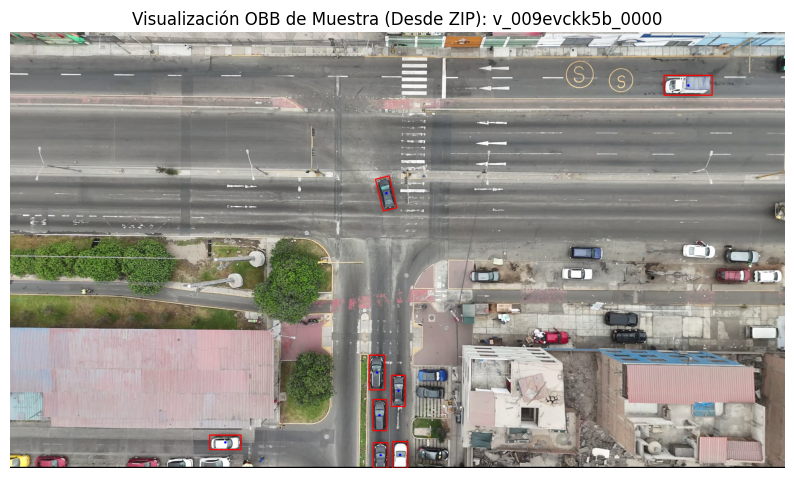

In [ ]:
import io
import zipfile

# Seleccionar un registro que contenga vehículos anotados para verificar visualmente
if os.path.exists(CSV_PATH) and os.path.exists(IMAGES_DIR): # IMAGES_DIR apunta a train.zip
    df_annotated = df_parsed[~df_parsed['class_id'].isna()]

    if not df_annotated.empty:
        sample = df_annotated.iloc[0]
        filename_to_find = f"{sample['Id']}.jpg"

        # Abrimos el archivo .zip en modo lectura
        with zipfile.ZipFile(IMAGES_DIR, 'r') as z:
            # Listamos los archivos internos para buscar la imagen (resuelve problemas si están dentro de una subcarpeta en el zip)
            zip_files = z.namelist()
            img_zip_path = [f for f in zip_files if f.endswith(filename_to_find)]

            if img_zip_path:
                # Leer los bytes de la imagen directamente desde el zip sin extraer a disco
                img_path_in_zip = img_zip_path[0]
                with z.open(img_path_in_zip) as file:
                    img_bytes = file.read()

                # Convertir los bytes en una matriz de NumPy y decodificarla con OpenCV
                nparr = np.frombuffer(img_bytes, np.uint8)
                img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

                # Convertir de BGR (OpenCV) a RGB (Matplotlib)
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Obtener todas las anotaciones del mismo frame
                frame_annotations = df_parsed[df_parsed['Id'] == sample['Id']]

                for _, ann in frame_annotations.iterrows():
                    cx, cy, w, h, angle = ann['cx'], ann['cy'], ann['w'], ann['h'], ann['angle']
                    rect = ((cx, cy), (w, h), angle)
                    box = cv2.boxPoints(rect)
                    box = np.int64(box) # np.int0 está deprecado en versiones nuevas de numpy, mejor usar np.int64 o np.int32

                    # Dibujar OBB en rojo y su centro
                    cv2.drawContours(img_rgb, [box], 0, (255, 0, 0), 2)
                    cv2.circle(img_rgb, (int(cx), int(cy)), 3, (0, 0, 255), -1)

                plt.figure(figsize=(10, 10))
                plt.imshow(img_rgb)
                plt.title(f"Visualización OBB de Muestra (Desde ZIP): {sample['Id']}")
                plt.axis('off')
                plt.show()
            else:
                print(f"No se encontró la imagen '{filename_to_find}' dentro del archivo ZIP.")
else:
    print("Verifica que existan tanto el CSV de anotaciones como el archivo ZIP de imágenes.")

In [ ]:
def check_class_distribution(df_parsed, df_train, df_val):
    """Calculates and validates that split class distributions do not deviate by >2%."""
    # Filter out empty frames (None targets)
    df_train_objs = df_train[~df_train['class_id'].isna()]
    df_val_objs = df_val[~df_val['class_id'].isna()]
    df_total_objs = df_parsed[~df_parsed['class_id'].isna()]

    total_train = len(df_train_objs)
    total_val = len(df_val_objs)
    total_all = len(df_total_objs)

    print("=== Class Distribution Parity Audit ===")
    print(f"Total instances - Train: {total_train} | Val: {total_val} | General: {total_all}\n")

    class_mapping = {
        0: "auto", 1: "combi", 2: "microbus", 3: "minibus", 4: "omnibus",
        5: "articulado", 6: "camion", 7: "mototaxi", 8: "motocicleta"
    }

    for cls in range(9):
        pct_total = (df_total_objs['class_id'] == cls).sum() / total_all * 100
        pct_train = (df_train_objs['class_id'] == cls).sum() / total_train * 100
        pct_val = (df_val_objs['class_id'] == cls).sum() / total_val * 100

        diff_train = abs(pct_train - pct_total)
        diff_val = abs(pct_val - pct_total)

        print(f"Class {cls} ({class_mapping[cls]}):")
        print(f"  Total: {pct_total:6.2f}%")
        print(f"  Train: {pct_train:6.2f}% (diff: {diff_train:5.2f}%)")
        print(f"  Val:   {pct_val:6.2f}% (diff: {diff_val:5.2f}%)")

        assert diff_train <= 2.0, f"Class {cls} train split deviation exceeds 2.0% absolute limit."
        assert diff_val <= 2.0, f"Class {cls} val split deviation exceeds 2.0% absolute limit."

    print("\n✓ All class distribution parity checks passed successfully (all deviations <= 2% absolute).")

if os.path.exists(CSV_PATH):
    check_class_distribution(df_parsed, df_train, df_val)


=== Class Distribution Parity Audit ===
Total instances - Train: 492486 | Val: 109448 | General: 601934

Class 0 (auto):
  Total:  80.03%
  Train:  79.66% (diff:  0.38%)
  Val:    81.72% (diff:  1.69%)
Class 1 (combi):
  Total:   1.69%
  Train:   1.70% (diff:  0.01%)
  Val:     1.65% (diff:  0.04%)
Class 2 (microbus):
  Total:   0.47%
  Train:   0.44% (diff:  0.02%)
  Val:     0.56% (diff:  0.10%)
Class 3 (minibus):
  Total:   3.15%
  Train:   3.22% (diff:  0.07%)
  Val:     2.83% (diff:  0.31%)
Class 4 (omnibus):
  Total:   0.38%
  Train:   0.36% (diff:  0.02%)
  Val:     0.47% (diff:  0.09%)
Class 5 (articulado):
  Total:   0.04%
  Train:   0.04% (diff:  0.00%)
  Val:     0.05% (diff:  0.00%)
Class 6 (camion):
  Total:   5.43%
  Train:   5.56% (diff:  0.14%)
  Val:     4.81% (diff:  0.61%)
Class 7 (mototaxi):
  Total:   0.92%
  Train:   0.89% (diff:  0.03%)
  Val:     1.05% (diff:  0.13%)
Class 8 (motocicleta):
  Total:   7.90%
  Train:   8.13% (diff:  0.23%)
  Val:     6.86% (diff: 

In [ ]:
# 7. YOLO OBB Geometric Conversion & Sample Dataset Generation
import zipfile

import yaml
from PIL import Image


def convert_obb_to_corners(cx, cy, w, h, angle_deg, W, H):
    """Converts parametric oriented bounding box in pixels to 4 normalized corners."""
    theta = np.radians(angle_deg)
    cos_t, sin_t = np.cos(theta), np.sin(theta)

    # 1. Local corner coordinates relative to box center
    dx = np.array([-w / 2, w / 2, w / 2, -w / 2])
    dy = np.array([-h / 2, -h / 2, h / 2, h / 2])

    # 2. Rotate and translate
    x_rot = dx * cos_t - dy * sin_t + cx
    y_rot = dx * sin_t + dy * cos_t + cy

    # 3. Normalize by image shape W, H and clip to [0.0, 1.0] range
    x_norm = np.clip(x_rot / W, 0.0, 1.0)
    y_norm = np.clip(y_rot / H, 0.0, 1.0)

    # Return corners in YOLO-OBB ordering: x1 y1 x2 y2 x3 y3 x4 y4
    return [
        float(x_norm[0]), float(y_norm[0]),
        float(x_norm[1]), float(y_norm[1]),
        float(x_norm[2]), float(y_norm[2]),
        float(x_norm[3]), float(y_norm[3])
    ]

def generate_sample_dataset(df_train, df_val, zip_path, output_dir, sample_train_clips=2, sample_val_clips=1):
    """Generates a small validated YOLO-OBB dataset for pipeline verification."""
    print(f"\n=== Generating Sample Dataset inside: {output_dir} ===")

    # Create directory structure
    for split in ['train', 'val']:
        os.makedirs(os.path.join(output_dir, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(output_dir, split, 'labels'), exist_ok=True)

    # Pick a subset of clips
    train_sample_clips = sorted(df_train['clip_id'].unique())[:sample_train_clips]
    val_sample_clips = sorted(df_val['clip_id'].unique())[:sample_val_clips]

    df_train_sub = df_train[df_train['clip_id'].isin(train_sample_clips)]
    df_val_sub = df_val[df_val['clip_id'].isin(val_sample_clips)]

    print(f"Selected Train clips: {train_sample_clips} ({df_train_sub['Id'].nunique()} frames)")
    print(f"Selected Val clips:   {val_sample_clips} ({df_val_sub['Id'].nunique()} frames)")

    with zipfile.ZipFile(zip_path, 'r') as z:
        zip_files = z.namelist()

        for split, df_sub in [('train', df_train_sub), ('val', df_val_sub)]:
            grouped = df_sub.groupby('Id')
            for frame_id, group in grouped:
                filename_to_find = f"{frame_id}.jpg"
                img_zip_paths = [f for f in zip_files if f.endswith(filename_to_find)]

                if not img_zip_paths:
                    print(f"Warning: Image {filename_to_find} not found in zip archive.")
                    continue

                img_zip_path = img_zip_paths[0]
                with z.open(img_zip_path) as file:
                    img_bytes = file.read()

                # Fetch exact image dimensions (W, H)
                with Image.open(io.BytesIO(img_bytes)) as img:
                    W, H = img.size

                # Save physical image
                dst_img_path = os.path.join(output_dir, split, 'images', filename_to_find)
                with open(dst_img_path, 'wb') as f_img:
                    f_img.write(img_bytes)

                # Generate matching OBB labels (.txt file)
                lbl_filename = f"{frame_id}.txt"
                dst_lbl_path = os.path.join(output_dir, split, 'labels', lbl_filename)

                with open(dst_lbl_path, 'w') as f_lbl:
                    for _, row in group.iterrows():
                        if pd.isna(row['class_id']):
                            continue  # Keep file empty for 'none' frames

                        corners = convert_obb_to_corners(
                            row['cx'], row['cy'], row['w'], row['h'], row['angle'], W, H
                        )
                        corners_str = " ".join([f"{c:.6f}" for c in corners])
                        f_lbl.write(f"{int(row['class_id'])} {corners_str}\n")

    # Write smart_dataset.yaml
    class_mapping = {
        0: "auto", 1: "combi", 2: "microbus", 3: "minibus", 4: "omnibus",
        5: "articulado", 6: "camion", 7: "mototaxi", 8: "motocicleta"
    }
    yaml_content = {
        "path": os.path.abspath(output_dir),
        "train": "train/images",
        "val": "val/images",
        "names": class_mapping
    }

    yaml_path = os.path.join(output_dir, "smart_dataset.yaml")
    with open(yaml_path, "w") as f_yaml:
        yaml.dump(yaml_content, f_yaml, default_flow_style=False, sort_keys=False)

    print(f"✓ Configuration YAML written to: {yaml_path}")
    print("✓ Sample dataset generation finished successfully.")

# Run generation
OUTPUT_DATASET_DIR = './sample_dataset'
if os.path.exists(CSV_PATH) and os.path.exists(IMAGES_DIR):
    generate_sample_dataset(
        df_train, df_val, IMAGES_DIR, OUTPUT_DATASET_DIR,
        sample_train_clips=2, sample_val_clips=1
    )



=== Generating Sample Dataset inside: ./sample_dataset ===
Selected Train clips: ['v_009evckk5b', 'v_016is7moli'] (100 frames)
Selected Val clips:   ['v_01tp2eyell'] (50 frames)
✓ Configuration YAML written to: ./sample_dataset/smart_dataset.yaml
✓ Sample dataset generation finished successfully.


In [13]:
# 1. Asegúrate de guardar los cambios en tu cuaderno (Ctrl + S) antes de correr esto.
# 2. Define las rutas de origen y destino

# Ruta de tu cuaderno actual en Drive (ajústala si tiene otro nombre)
CUADERNO_PATH = "/content/drive/MyDrive/Colab Notebooks/prototipo_prep.ipynb"
# Directorio de tu proyecto donde quieres guardar el Markdown y sus imágenes
DESTINO_DIR = "/content/drive/MyDrive/ia_article/temp"

# Ejecutamos la conversión redirigiendo la salida
!jupyter nbconvert --to markdown "$CUADERNO_PATH" --output-dir="$DESTINO_DIR"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/prototipo_prep.ipynb to markdown
[NbConvertApp] Support files will be in prototipo_prep_files/
[NbConvertApp] Writing 24176 bytes to /content/drive/MyDrive/ia_article/temp/prototipo_prep.md
